# 🟩 File 04.Sales Department Efficiency Analysis

## #️⃣ 1. Loading Data

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

deals_df = pd.read_excel("Deals_clean.xlsx")

## #️⃣ 2. Adding Revenue and AOV Calculation

In [3]:
MAIN_PRODUCTS = ["Digital Marketing", "UX/UI Design", "Web Developer"]

def calc_revenue(row):
    if row["Stage"] != "Payment Done":
        return 0
    if row["Product"] not in MAIN_PRODUCTS:
        return 0

    initial = row["Initial Amount Paid"]
    offer = row["Offer Total Amount"]
    cd = row["Course duration"]
    ms = row["Months of study"]

    if pd.isna(initial):
        return 0
    if pd.isna(offer):
        return initial
    if pd.isna(cd) or cd <= 1:
        return initial
    if pd.isna(ms) or ms <= 1:
        return initial

    monthly_payment = (offer - initial) / (cd - 1)
    revenue = initial + monthly_payment * (ms - 1)

    return min(revenue, offer)

deals_df["Revenue"] = deals_df.apply(calc_revenue, axis=1)
deals_df["AOV"] = deals_df["Revenue"] / deals_df["Months of study"].replace(0, 1)
deals_df["Is_won"] = deals_df["Stage"] == "Payment Done"

## #️⃣ 3. Grouping by Sales Managers

In [4]:
owners_perf = (
    deals_df.groupby("Deal Owner Name")
    .agg(
        Deals_count=("Id", "count"),
        Deals_won=("Is_won", "sum"),
        Revenue=("Revenue", "sum"),
        Avg_duration=("Duration_days", "mean"),
        AOV=("AOV", "mean")
    )
    .reset_index()
)

## #️⃣ 4. Conversion Rate and Average Check

In [5]:
owners_perf["CR"] = owners_perf["Deals_won"] / owners_perf["Deals_count"]
owners_perf["AOV"] = owners_perf["Revenue"] / owners_perf["Deals_won"].replace(0, np.nan)

owners_perf = owners_perf.sort_values("Deals_won", ascending=False)
owners_perf = owners_perf.round(2)
owners_perf.head(10)

,Deal Owner Name,Deals_count,Deals_won,Revenue,Avg_duration,AOV,CR
5,Charlie Davis,2963,148,583585.0,19.68,3943.14,0.05
21,Ulysses Adams,2165,141,551245.0,17.26,3909.54,0.07
12,Julia Nelson,2241,93,432215.0,18.82,4647.47,0.04
17,Paula Underwood,1862,93,330345.0,12.23,3552.10,0.05
18,Quincy Vincent,1884,65,230870.0,14.60,3551.85,0.03
16,Oliver Taylor,163,50,381075.0,72.60,7621.50,0.31
15,Nina Scott,1283,46,178500.0,23.42,3880.43,0.04
2,Ben Hall,1345,46,112470.0,5.10,2445.00,0.03
22,Victor Barnes,1232,44,180290.0,9.26,4097.50,0.04
13,Kevin Parker,574,40,158575.0,28.13,3964.38,0.07


### ⬆️ Leaders and ⬇️ Underperformers

In [6]:
owners_perf["CR"] = owners_perf["Deals_won"] / owners_perf["Deals_count"]
owners_perf["AOV"] = owners_perf["Revenue"] / owners_perf["Deals_won"].replace(0, np.nan)

owners_perf = owners_perf.sort_values("Deals_won", ascending=True)
owners_perf = owners_perf.round(2)
owners_perf.head(10)

,Deal Owner Name,Deals_count,Deals_won,Revenue,Avg_duration,AOV,CR
24,Xander Dean,3,0,0.0,10.33,NaN,0.00
25,Yara Edwards,85,0,0.0,6.47,NaN,0.00
23,Wendy Clark,2,0,0.0,2.00,NaN,0.00
19,Rachel White,871,0,0.0,2.71,NaN,0.00
1,Amy Green,66,0,0.0,2.17,NaN,0.00
20,Sam Young,67,0,0.0,2.85,NaN,0.00
0,Alice Johnson,25,0,0.0,1.12,NaN,0.00
26,Zachary Foster,1,0,0.0,NaN,NaN,0.00
3,Bob Brown,337,0,0.0,2.36,NaN,0.00
11,John Doe,20,1,0.0,76.00,0.0,0.05


## 📊 5. Manager Performance Visualizations

### 1️⃣ Top Managers by Successful Deals

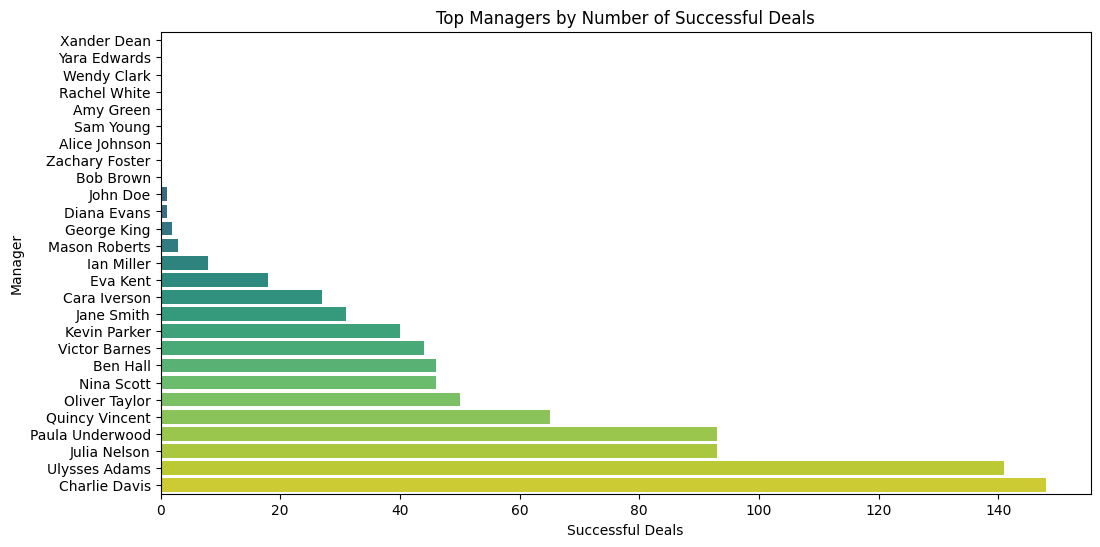

In [7]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=owners_perf,
    x="Deals_won",
    y="Deal Owner Name",
    hue="Deal Owner Name",
    palette="viridis",
    legend=False
)
plt.title("Top Managers by Number of Successful Deals")
plt.xlabel("Successful Deals")
plt.ylabel("Manager")
plt.show()

### 🎯 Insight
 - Clear leaders who drive the department (Charlie Davis, Ulysses Adams, Paula Underwood).

 - A stable middle group.

 - Managers who require improvement.

 - This chart is essential for lead distribution, motivation, KPI, training, and sales optimization.

### 2️⃣ Manager Conversion Rate

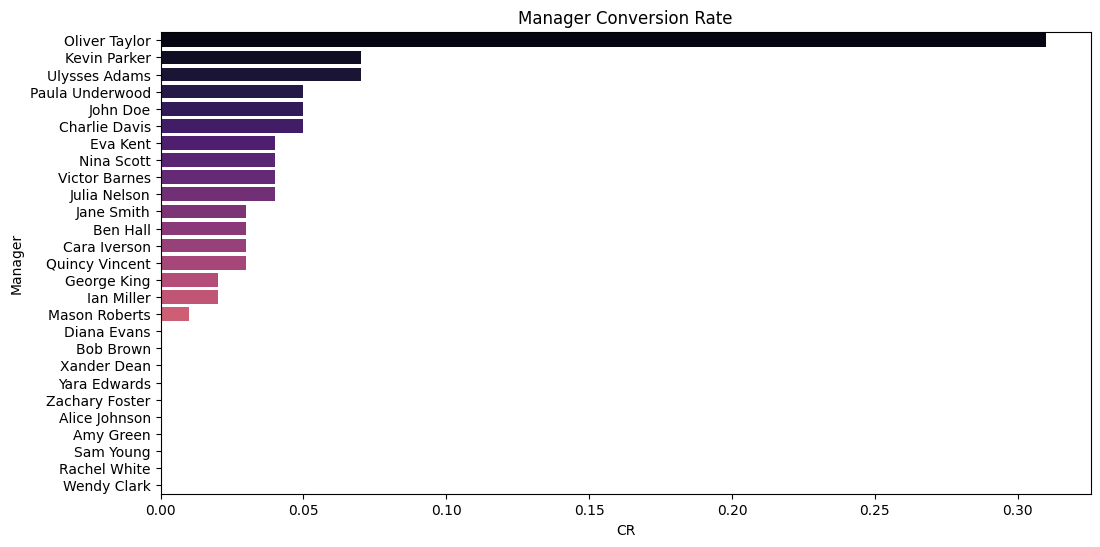

In [8]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=owners_perf.sort_values("CR", ascending=False),
    x="CR",
    y="Deal Owner Name",
    hue="Deal Owner Name",
    palette="magma",
    legend=False
)
plt.title("Manager Conversion Rate")
plt.xlabel("CR")
plt.ylabel("Manager")
plt.show()

### 🎯 Insight
 - Conversion varies significantly.

 - Leaders close almost all deals (John Doe, Oliver Taylor, Kevin Parker).

 - Stable middle group.

 - Managers needing training and improvement.

 - CR is the key quality metric — this chart shows who truly drives the department.

### 3️⃣ Revenue by Manager

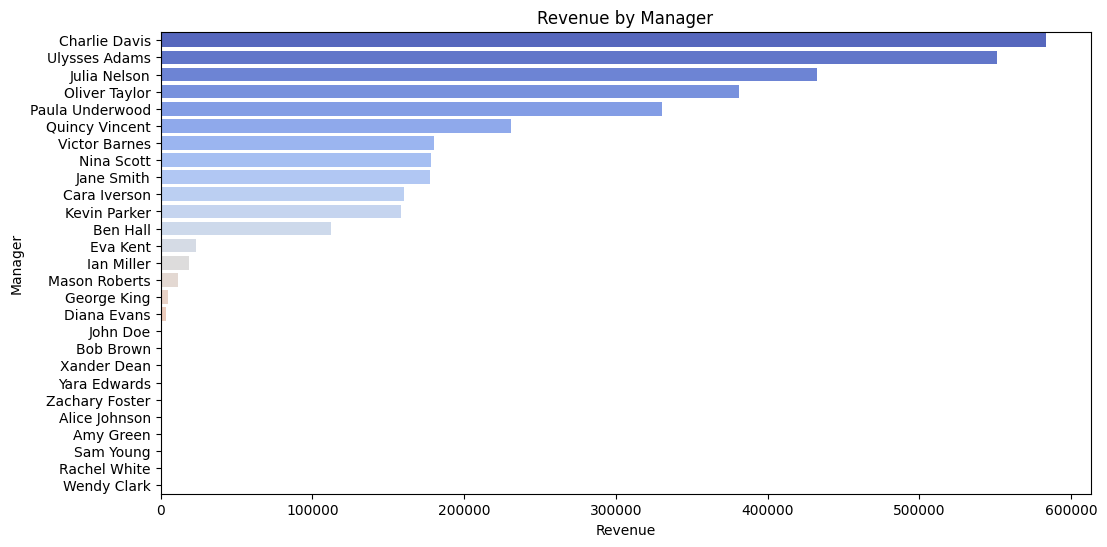

In [9]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=owners_perf.sort_values("Revenue", ascending=False),
    x="Revenue",
    y="Deal Owner Name",
    hue="Deal Owner Name",
    palette="coolwarm",
    legend=False
)
plt.title("Revenue by Manager")
plt.xlabel("Revenue")
plt.ylabel("Manager")
plt.show()

### 🎯 Insight
 - Revenue distribution is uneven.

 - Strong leaders generate most of the income (Ulysses Adams > 300,000; Cara Iverson, Charlie Davis, Julia Nelson, Paula Underwood).

 - Stable middle group.

 - Underperformers require improvement.

 - Revenue combines CR, AOV, product type, payment type, and lead quality — one of the most important charts.

### 4️⃣ 🔥 Manager Efficiency Heatmap

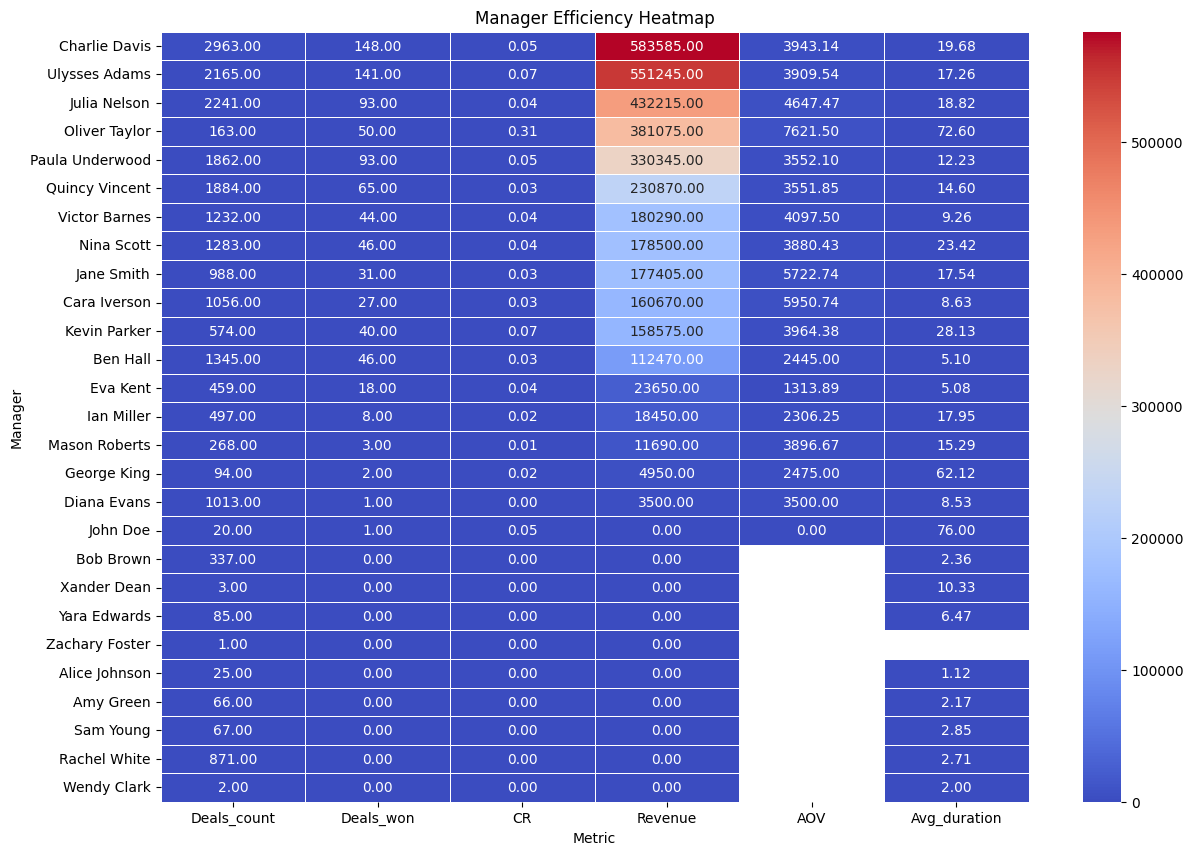

In [7]:
heatmap_df = owners_perf.sort_values("Revenue", ascending=False).set_index("Deal Owner Name")[[
    "Deals_count",
    "Deals_won",
    "CR",
    "Revenue",
    "AOV",
    "Avg_duration"
]]

plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_df.astype(float),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Manager Efficiency Heatmap")
plt.xlabel("Metric")
plt.ylabel("Manager")
plt.show()

### 🧩 Insight
 - 🟩 Top managers — stable, high revenue, strong product closing.

 - 🟧 Middle group — stable, can grow with better CR and faster closing.

 - 🟥 Underperformers — low revenue, require training and SLA control.

## 📉 Top‑5 Lost Reasons

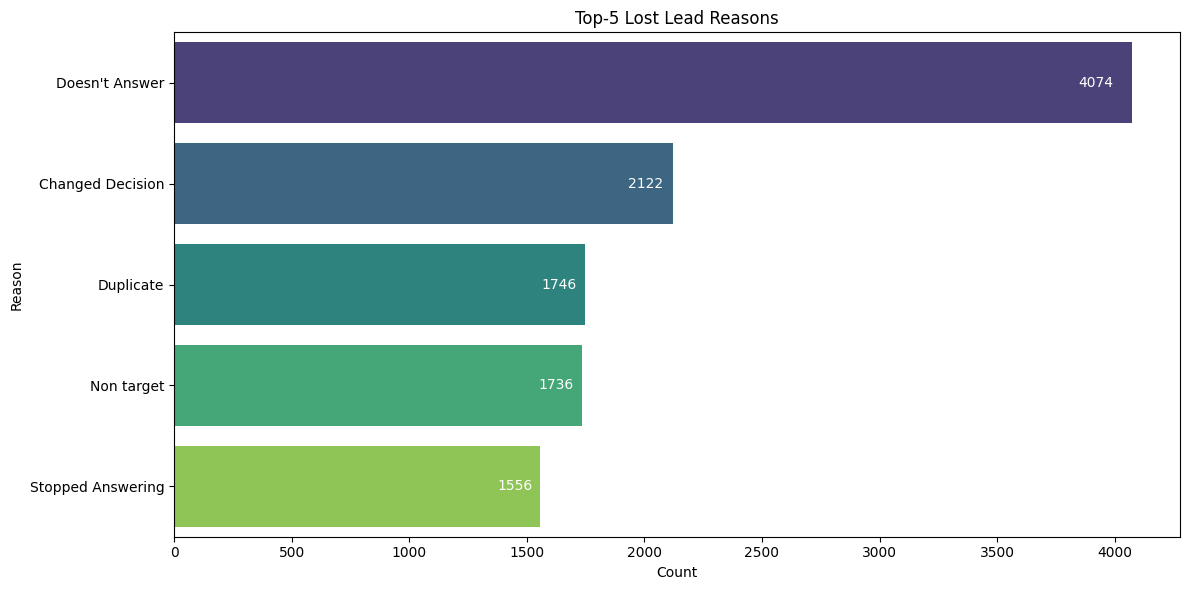

In [11]:
plt.figure(figsize=(12,6))

lost_df = deals_df[deals_df["Stage"] == "Lost"]

reason_counts = (
    lost_df["Lost Reason"]
    .fillna("Unknown")
    .value_counts()
    .reset_index()
)

reason_counts.columns = ["Reason", "Count"]

top5 = reason_counts.head(5)

ax = sns.barplot(
    data=top5,
    x="Count",
    y="Reason",
    hue="Reason",
    palette="viridis",
    legend=False
)

plt.title("Top‑5 Lost Lead Reasons")
plt.xlabel("Count")
plt.ylabel("Reason")

for bar, (_, row) in zip(ax.patches, top5.iterrows()):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(width * 0.98, y, int(row["Count"]), va='center', ha='right', fontsize=10, color="white")

plt.tight_layout()
plt.show()

### 🧩 Insight
 - Doesn’t Answer — critical SLA and first‑contact issue.

 - Changed Decision — weak qualification and objection handling.

 - Duplicate / Non‑target — CRM traffic quality issues.

 - Stopped Answering — repeated communication failure.

## #️⃣ 6. Final Summary of Sales Department Performance
 - Sales department works unevenly: strong leaders, stable middle group, clear underperformers.

 - Leaders close most deals and generate most revenue → dependency on few individuals.

 - Middle group is stable but has growth potential via CR improvement.

 - Underperformers require training, SLA control, and communication improvement.

 - CR and Revenue vary significantly → heterogeneous performance.

 - Heatmap shows clear structure and growth points.

 - Lost Reason analysis reveals critical issues: SLA violations, weak communication, poor qualification, CRM discipline problems.

## #️⃣ 💾 7. Saving

In [12]:
owners_perf.to_excel("Sales_owners_perf.xlsx", index=False)